In [141]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import importlib
from torchinfo import summary
import time
import pandas as pd
import pybamm


import sys
sys.path.append('..')
import plot_settings
plot_settings.apply()
import sim_PyBaMM
importlib.reload(sim_PyBaMM);
import exp_pybamm_ver4
importlib.reload(exp_pybamm_ver4);

sys.path.append('../nn_model')
from nn_model_lib import *
importlib.reload(nn_model_lib);

print(sim_PyBaMM.__file__)
print(exp_pybamm_ver4.__file__) 

/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/_moving_box/data_pybamm/sim_PyBaMM.py
/Users/noord/Desktop/MSc_git_new/MSc_thesis/program/_moving_box/data_pybamm/exp_pybamm_ver4.py


In [77]:
# --- Data generation ---

translator = {
    'I': 'Current [A]',
    'V': 'Terminal voltage [V]',
    'cn': 'X-averaged negative particle concentration [mol.m-3]',
    'cp': 'X-averaged positive particle concentration [mol.m-3]',
    'cns': 'X-averaged negative particle surface concentration [mol.m-3]',
    'cps': 'X-averaged positive particle surface concentration [mol.m-3]',
    'ocv': 'Battery open-circuit voltage [V]',
}

translator_inv = {v: k for k, v in translator.items()}

data_cols = ['I', 'V', 'ocv']

def gen_cols(data_cols, translator=translator):
    '''Extracting variable names from translator dict for given data_cols'''
    return [translator[col] for col in data_cols]



def time_query(sol, t_fixed):
    t_end = sol["Time [s]"].entries[-1]
    valid = t_fixed <= t_end  # boolean, length T # Valid mask: where simulation was still running
    t_query = np.clip(t_fixed, 0, t_end)     # Observe only up to t_end, fill rest with NaN or last value
    return t_query, valid

def observe_states(t_query, sol, model, data_cols):
    data = pd.DataFrame(index=t_query)
    cols = gen_cols(data_cols)
    for col in cols:
        data[translator_inv[col]] = sol.observe(model.variables[col])(t_query)
    return data

def get_vals_CC(I0, get_Ue, data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_CC(I0, T, T_HORIZON, get_Ue)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_pulse(data_cols=data_cols):
    sol, model, t_eval, param = exp_pybamm_ver4.generate_data(T_HORIZON, DT, RNG=None)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model

def get_vals_GRF(data_cols=data_cols):
    sol, model, param = sim_PyBaMM.simulate_GRF(T, T_HORIZON)   # simulate with t_eval = np.linspace(0, t_horizon, T)
    t_query, valid = time_query(sol, t_fixed)
    data = observe_states(t_query, sol, model, data_cols)
    return data, valid, param, sol, model


def gen_data(B, data_cols, currents='CC', I_low=0.25, I_high=1.0, seed=None, get_Ue=False):
    '''Generate trajectories with shape (B, T, D)'''

    rng = np.random.default_rng(seed)

    dot_cols = [f"{k}_dot" for k in data_cols if k in ['cn','cp']]
    all_cols = data_cols + ['dI'] + dot_cols + ['valid']

    D = len(all_cols)

    X = np.zeros((B, T, D))
    var_index = {k:i for i,k in enumerate(all_cols)}

    for b in trange(B):

        if currents == 'CC':
            data, valid_b, param, sol, model = get_vals_CC(float(rng.uniform(I_low, I_high)), get_Ue=get_Ue)
        elif currents == 'pulse':
            data, valid_b, param, sol, model = get_vals_pulse()
        elif currents == 'GRF':
            data, valid_b, param, sol, model = get_vals_GRF()
        else:
            raise ValueError("Invalid current type")

        # base variables
        for col in data_cols:
            X[b, :, var_index[col]] = data[col].values

        # dI
        if 'I' in data_cols:
            I = data['I'].values
            dI = np.zeros_like(I)
            dI[1:] = np.diff(I)
            X[b, :, var_index['dI']] = dI

        # derivatives
        for col in ['cn','cp']:
            if col in data_cols:
                x = data[col].values
                xdot = np.zeros_like(x)
                xdot[:-1] = np.diff(x) / DT
                xdot[-1] = xdot[-2]
                X[b, :, var_index[f"{col}_dot"]] = xdot

        # valid mask
        X[b, :, var_index['valid']] = valid_b.astype(float)

    return X, var_index, param, sol, model

In [78]:
import numpy as np
import pandas as pd

def save_pybamm_dataset(X, var_index, t_grid, path, *, pulse=False, Q_ah=1.0, soc0=1.0, save=True):
    cols = ['u_par','C','t','V','I','F','u','Ue','soc','eta','pulse','trajectory']
    iI, iV, iOcv, iValid = (var_index['I'], var_index['V'],
                            var_index['ocv'], var_index['valid'])
    frames = []
    for b in range(X.shape[0]):
        valid = X[b, :, iValid].astype(bool)
        t  = np.asarray(t_grid)[valid]
        I  = X[b, valid, iI]
        V  = X[b, valid, iV]
        Ue = X[b, valid, iOcv]
        # Coulomb-counted SOC (discharge positive): soc = soc0 - integral(I dt)/(Q*3600)
        charge_As = np.concatenate([[0.0], np.cumsum(0.5*(I[1:]+I[:-1])*np.diff(t))])
        soc = soc0 - charge_As / (Q_ah * 3600.0)
        frames.append(pd.DataFrame({
            'u_par': 0, 'C': I / Q_ah, 't': t, 'V': V, 'I': I,
            'F': 0, 'u': 0, 'Ue': Ue, 'soc': soc,
            'eta': Ue - V, 'pulse': pulse, 'trajectory': b,
        }, columns=cols))
    out = pd.concat(frames, ignore_index=True)
    out.to_csv(path, sep=';', index=False, na_rep='') if save else None
    return out

## Generate data

In [111]:
# --- Simulation config ---
T_HORIZON = 30*3600.0          # [s]  total simulation horizon
T = 3600*3           # number of time steps
DT = T_HORIZON / (T)   # fixed for all sims
t_fixed = np.linspace(0, T_HORIZON, T)    # fixed 'physical' grid

In [142]:
X, var_index, param, sol, model = gen_data(1, data_cols, currents='CC', I_low=0.05, I_high=1.5, seed=42, get_Ue=True)
print("Data shape:", X.shape)
print("Variable index:", var_index)

data = save_pybamm_dataset(X, var_index, t_fixed, 'test.txt', pulse=False, save=False)
display(data)

100%|██████████| 1/1 [00:00<00:00,  1.02it/s]

Data shape: (1, 10800, 5)
Variable index: {'I': 0, 'V': 1, 'ocv': 2, 'dI': 3, 'valid': 4}


,u_par,C,t,V,I,F,u,Ue,soc,eta,pulse,trajectory
0,0,0.033333,0.000000,4.094951,0.033333,0,0,4.100000,1.000000,0.005049,False,0
1,0,0.033333,10.000926,4.094403,0.033333,0,0,4.099912,0.999907,0.005509,False,0
2,0,0.033333,20.001852,4.094104,0.033333,0,0,4.099823,0.999815,0.005719,False,0
3,0,0.033333,30.002778,4.093871,0.033333,0,0,4.099734,0.999722,0.005863,False,0
4,0,0.033333,40.003704,4.093676,0.033333,0,0,4.099645,0.999630,0.005969,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9410,0,0.033333,94108.713770,3.115172,0.033333,0,0,3.143076,0.128623,0.027904,False,0
9411,0,0.033333,94118.714696,3.112753,0.033333,0,0,3.140733,0.128530,0.027980,False,0
9412,0,0.033333,94128.715622,3.110330,0.033333,0,0,3.138381,0.128438,0.028051,False,0
9413,0,0.033333,94138.716548,3.107911,0.033333,0,0,3.136020,0.128345,0.028109,False,0


## Visualize data

Capacity used: 0.8717646987770797, Nominal capacity: 1.0, Voltage cutoff: 3.105, Final SOC: 0.12825261598304905


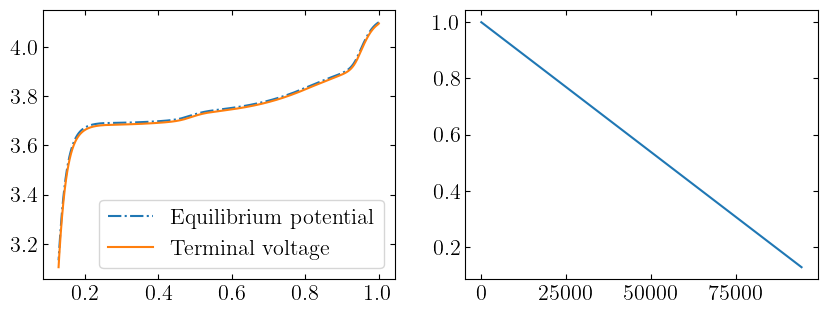

In [143]:
Q_used = sol["Discharge capacity [A.h]"].entries[-1]   # at end of a full CC discharge to cutoff
Q_ah = param['Nominal cell capacity [A.h]']
V_min = param['Lower voltage cut-off [V]']
print(f'Capacity used: {Q_used}, Nominal capacity: {Q_ah}, Voltage cutoff: {V_min}, Final SOC: {data["soc"].values[-1]}')

fig, axes= plt.subplots(1, 2, figsize=(10,3.5))
# axes[0].plot(data['t'], data['Ue'], '-.', label='Equilibrium potential')
# axes[0].plot(data['t'], data['V'], '-', label='Terminal voltage')
axes[0].plot(data['soc'], data['Ue'], '-.', label='Equilibrium potential')
axes[0].plot(data['soc'], data['V'], '-', label='Terminal voltage')
axes[0].legend()
axes[1].plot(data['t'], data['soc'])
axes[1].plot(Q_used)

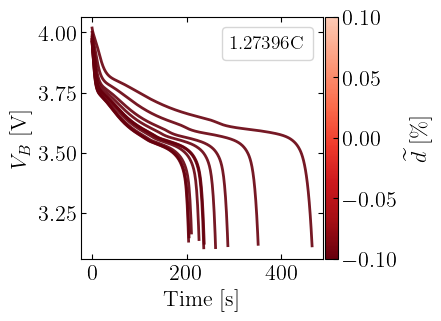

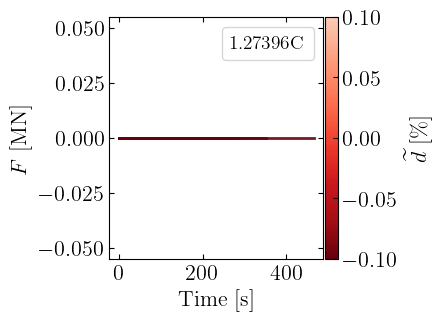

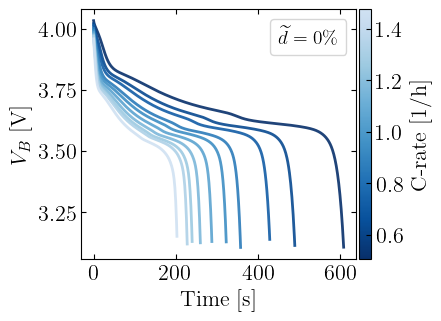

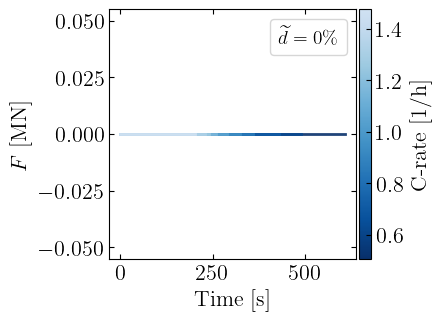

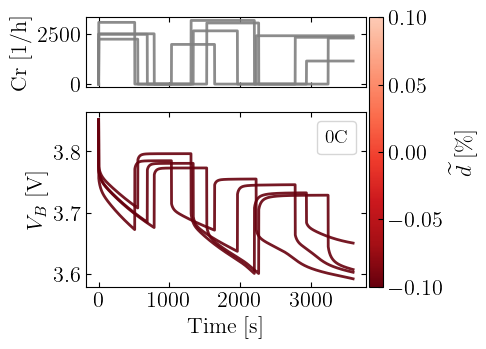

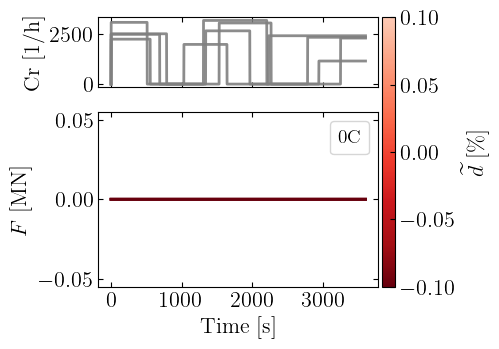

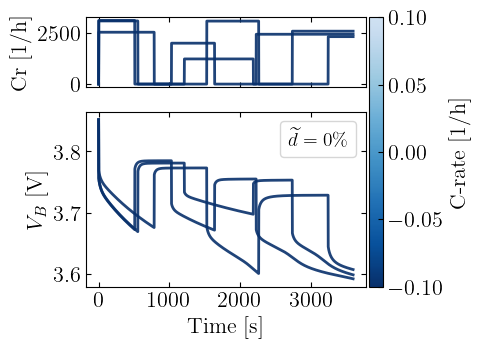

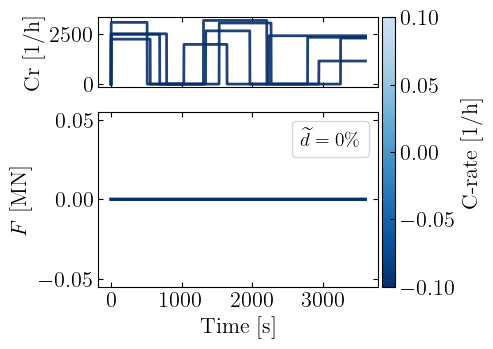

In [126]:
def plot_data_report(trajs, *, sort='C_rate', present='V', n_show=5, pulse=False,
                     Q0=1):
    """Two-panel (pulse) or single-panel (CC) raw-data plot.
    
    pulse=True  → current panel (top, compact) + voltage panel (bottom),
                  shared colorbar across both.
    pulse=False → voltage panel only, with a fixed-value tag showing the
                  constant of the non-swept variable.
    """
    if sort == 'C_rate':
        trajs_sorted = sorted(trajs, key=lambda tr: tr['C'])
        vals_arr = np.array([tr['C'] for tr in trajs_sorted])
        bar_name = 'C-rate [1/h]'
    elif sort == 'u_per':
        trajs_sorted = sorted(trajs, key=lambda tr: tr['u_per'])
        vals_arr = np.array([tr['u_per'] for tr in trajs_sorted])
        bar_name = r'$\widetilde{d}$ [\%]'
    else:
        raise ValueError(f"sort must be 'C_rate' or 'u_per', got {sort!r}")
    norm = Normalize(vmin=vals_arr.min(), vmax=vals_arr.max())

    if n_show is None or n_show >= len(trajs_sorted):
        trajs_plot = trajs_sorted
    else:
        start = 2 if pulse else 0
        idx = np.unique(np.linspace(start, len(trajs_sorted) - 1, n_show).round().astype(int))
        trajs_plot = [trajs_sorted[i] for i in idx]

    base = plt.cm.Blues_r
    cmap = LinearSegmentedColormap.from_list(
        "Blues_custom", base(np.linspace(0.0, 0.8, 256)))
    base = plt.cm.Reds_r
    cmap_r = LinearSegmentedColormap.from_list(
        "Reds_custom", base(np.linspace(0.0, 0.8, 256)))

    # ── layout ──────────────────────────────────────────────────────────
    if pulse:
        fig, ax = plt.subplot_mosaic(
            [['current'], ['voltage']],
            figsize=(4.3, 3.5),
            # figsize=(4.3, 3.64),
            height_ratios=[0.4, 1.0],
            sharex=True, 
            #constrained_layout=True,
        )
        ax_i, ax_v = ax['current'], ax['voltage']
    else:
        fig, ax_v = plt.subplots(figsize=(4.3, 3.1), constrained_layout=True)
        ax_i = None

    I_to_C = 3600.0 / Q0

    # ── plot ────────────────────────────────────────────────────────────
    for tr in trajs_plot:
        bar_val = float(tr['C']) if sort == 'C_rate' else float(tr['u_per'])
        color = cmap(norm(bar_val)) if sort == 'C_rate' else cmap_r(norm(bar_val))

        t = np.arange(tr['T'])
        V = tr['V'].numpy() if hasattr(tr['V'], 'numpy') else np.asarray(tr['V'])
        F = tr['F'].numpy() if hasattr(tr['F'], 'numpy') else np.asarray(tr['F'])
        if present == 'V':
            ax_v.plot(t, V, color=color, lw=2, alpha=0.9)
        elif present == 'F':
            ax_v.plot(t, F * 1e3, color=color, lw=2, alpha=0.9)

        if pulse and 'I_seq' not in tr:
            raise ValueError(
                "pulse=True but trajectory has no 'I_seq' — did you use prepare_data instead of prepare_pulse_data?")
        if pulse:
            if 'I_seq' in tr:
                I = tr['I_seq'].numpy() if hasattr(tr['I_seq'], 'numpy') else np.asarray(tr['I_seq'])
            else:
                I = tr['I'] * np.ones_like(t)
            ax_i.plot(t, I * I_to_C, color=color if sort == 'C_rate' else 'gray', lw=2, alpha=0.9)

    if present == 'V':
        ax_v.set_ylabel(r'$V_B$ [V]')
    elif present == 'F':
        ax_v.set_ylabel(r'$F$ [MN]')
    ax_v.set_xlabel('Time [s]')

    # Fixed-value tag — value of the variable not being swept
    first = trajs_plot[0]
    if sort == 'u_per':
        tag = fr'${float(first["C"]):g}$C'
    else:   # sort == 'C_rate'
        tag = fr'$\widetilde{{d}} = {float(first["u_per"]):g}\%$'

    ax_v.legend(handles=[plt.Line2D([0], [0], color='none', label=tag)], loc='upper right',
                 frameon=True, handlelength=0, handletextpad=0, fontsize=14)
    if pulse:
        ax_i.set_ylabel('Cr [1/h]')
        # ax_v.set_xlim(-100, 3200)
    # else:
    #     ax_v.legend(handles=[plt.Line2D([0], [0], color='none', label=tag)], loc='upper right', frameon=True, handlelength=0, handletextpad=0)
    

    sm = ScalarMappable(cmap=cmap if sort == 'C_rate' else cmap_r, norm=norm)
    sm.set_array([])
    cbar_ax = [ax_i, ax_v] if pulse else ax_v
    fig.colorbar(sm, ax=cbar_ax, label=bar_name, location='right', pad=0.01)
    

    # for pulses u_per
    # ax_v.set_xlim(-100, 3200)

    return fig

def read_data(file_name):
    df = pd.read_csv(
        f"{file_name}",
        sep=';',
        comment="%"
    )
    return df

# ––––––– CC –––––––––––––––––––––––––––––––––––––––––––––––––––––
data_cc = read_data('CC/pybamm_CC.txt')
trajs = prepare_data(data_cc)
plot_data_report(trajs, sort='u_per', present='V', n_show=10)
# plt.savefig('data_figs/CC_u_sweep_V.pdf', bbox_inches='tight')
plt.show()

plot_data_report(trajs, sort='u_per', present='F', n_show=10)
# plt.savefig('data_figs/CC_u_sweep_F.pdf', bbox_inches='tight')
plt.show()

trajs_d0 = prepare_data(data_cc[data_cc['u_par'] == 0])
plot_data_report(trajs_d0, sort='C_rate', n_show=10)
# plt.savefig('data_figs/CC_c_sweep_V.pdf', bbox_inches='tight')
plt.show()

plot_data_report(trajs_d0, sort='C_rate', present='F', n_show=10)
# plt.savefig('data_figs/CC_c_sweep_F.pdf', bbox_inches='tight')
plt.show()

# # –––––––– Pulse –––––––––––––––––––––––––––––––––––––––––––––––––––
data_pulse = read_data('pulse/pybamm_pulse.txt')
pulse_trajs = prepare_pulse_data(data_pulse)
plot_data_report(pulse_trajs, sort='u_per', present='V', n_show=4, pulse=True)
# plt.savefig('data_figs/pulse_u_sweep_V.pdf', bbox_inches='tight')
plt.show()

data_pulse = read_data('pulse/pybamm_pulse.txt')
pulse_trajs = prepare_pulse_data(data_pulse)
plot_data_report(pulse_trajs, sort='u_per', present='F', n_show=4, pulse=True)
# plt.savefig('data_figs/pulse_u_sweep_F.pdf', bbox_inches='tight')
plt.show()

data_pulse_old = read_data('pulse/pybamm_pulse.txt')
pulse_trajs_d0 = prepare_pulse_data(data_pulse_old[(data_pulse_old['u_par'] == 0) & (data_pulse_old['pulse'] == True)])
plot_data_report(pulse_trajs_d0, sort='C_rate', present='V', n_show=3, pulse=True)
# plt.savefig('data_figs/pulse_c_sweep_V.pdf', bbox_inches='tight')
plt.show()


data_pulse_old = read_data('pulse/pybamm_pulse.txt')
pulse_trajs_d0 = prepare_pulse_data(data_pulse_old[(data_pulse_old['u_par'] == 0) & (data_pulse_old['pulse'] == True)])
plot_data_report(pulse_trajs_d0, sort='C_rate', present='F', n_show=4, pulse=True)
# plt.savefig('data_figs/pulse_c_sweep_F.pdf', bbox_inches='tight')
plt.show()